In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
data = pd.read_csv('data.csv.zip')
data.head(5)

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


In [4]:
data.tail(5)

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
11909,Acura,ZDX,2012,premium unleaded (required),300.0,6.0,AUTOMATIC,all wheel drive,4.0,"Crossover,Hatchback,Luxury",Midsize,4dr Hatchback,23,16,204,46120
11910,Acura,ZDX,2012,premium unleaded (required),300.0,6.0,AUTOMATIC,all wheel drive,4.0,"Crossover,Hatchback,Luxury",Midsize,4dr Hatchback,23,16,204,56670
11911,Acura,ZDX,2012,premium unleaded (required),300.0,6.0,AUTOMATIC,all wheel drive,4.0,"Crossover,Hatchback,Luxury",Midsize,4dr Hatchback,23,16,204,50620
11912,Acura,ZDX,2013,premium unleaded (recommended),300.0,6.0,AUTOMATIC,all wheel drive,4.0,"Crossover,Hatchback,Luxury",Midsize,4dr Hatchback,23,16,204,50920
11913,Lincoln,Zephyr,2006,regular unleaded,221.0,6.0,AUTOMATIC,front wheel drive,4.0,Luxury,Midsize,Sedan,26,17,61,28995


df = df.drop(['Engine Fuel Type', 'Market Category', 'Vehicle Style', 'Popularity', 'Number of Doors', 'Vehicle Size'], axis=1)

In [10]:
data.head(5)

,Make,Model,Year,Engine HP,Engine Cylinders,Transmission Type,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,335.0,6.0,MANUAL,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,300.0,6.0,MANUAL,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,300.0,6.0,MANUAL,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,230.0,6.0,MANUAL,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,230.0,6.0,MANUAL,Convertible,28,18,3916,34500


In [11]:
data.isnull().sum()

,0
Make,0
Model,0
Year,0
Engine HP,69
Engine Cylinders,30
Transmission Type,0
Vehicle Style,0
highway MPG,0
city mpg,0
Popularity,0


In [13]:
data = data[~data['Engine HP'].isnull()].copy()

In [15]:
data = data[~data['Engine Cylinders'].isnull()].copy()

In [16]:
data.isnull().sum()

,0
Make,0
Model,0
Year,0
Engine HP,0
Engine Cylinders,0
Transmission Type,0
Vehicle Style,0
highway MPG,0
city mpg,0
Popularity,0


In [18]:
data = data.rename(columns={'Engine HP':'hp','Engine Cylinders':'cylenders','Transmission Type':'Transmission','highway MPG':'mpg','Vehicle Style':'style'})
data.head(5)

,Make,Model,Year,hp,cylenders,Transmission,style,mpg,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,335.0,6.0,MANUAL,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,300.0,6.0,MANUAL,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,300.0,6.0,MANUAL,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,230.0,6.0,MANUAL,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,230.0,6.0,MANUAL,Convertible,28,18,3916,34500


In [19]:
data.shape

(11816, 11)

In [21]:
duplicate_rows=data[data.duplicated()]
print('number of duplicate rows',duplicate_rows.shape)

number of duplicate rows (828, 11)


In [22]:
data.count()

,0
Make,11816
Model,11816
Year,11816
hp,11816
cylenders,11816
Transmission,11816
style,11816
mpg,11816
city mpg,11816
Popularity,11816


In [23]:
data=data.drop_duplicates()
data.head(5)

,Make,Model,Year,hp,cylenders,Transmission,style,mpg,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,335.0,6.0,MANUAL,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,300.0,6.0,MANUAL,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,300.0,6.0,MANUAL,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,230.0,6.0,MANUAL,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,230.0,6.0,MANUAL,Convertible,28,18,3916,34500


In [24]:
data.count()

,0
Make,10988
Model,10988
Year,10988
hp,10988
cylenders,10988
Transmission,10988
style,10988
mpg,10988
city mpg,10988
Popularity,10988


In [45]:
data = data.rename(columns={ "MSRP": "Price" })

**Univariate Analysis**

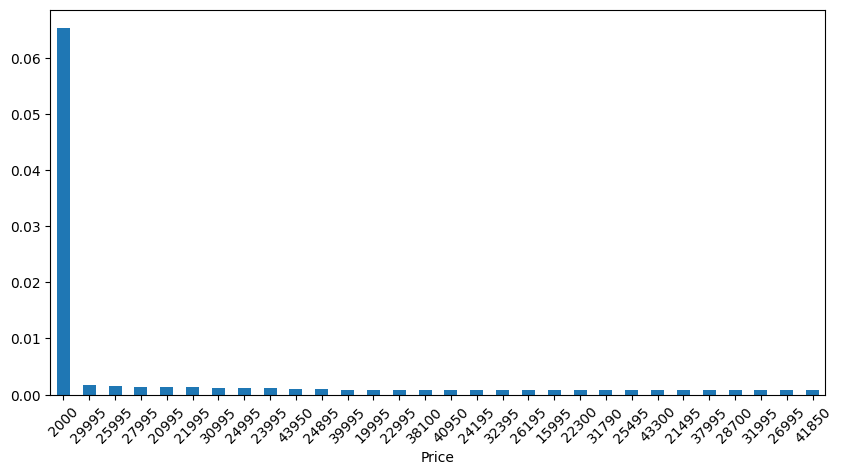

In [48]:
data['Price'].value_counts(normalize=True).head(30).plot(kind='bar', figsize=(10, 5))
plt.xticks(rotation=45)  # Rotate labels for readability
plt.show()

detecting outliers


<Axes: xlabel='Price'>

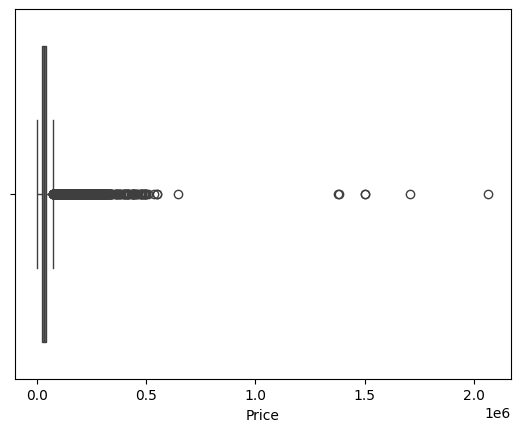

In [50]:
sns.boxplot(x=data['Price'])

<Axes: xlabel='hp'>

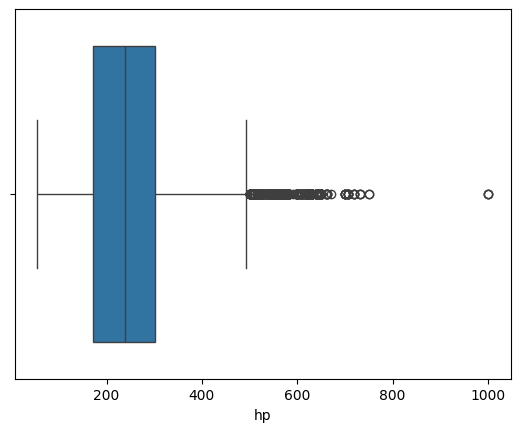

In [52]:
sns.boxplot(x=data['hp'])

<Axes: xlabel='cylenders'>

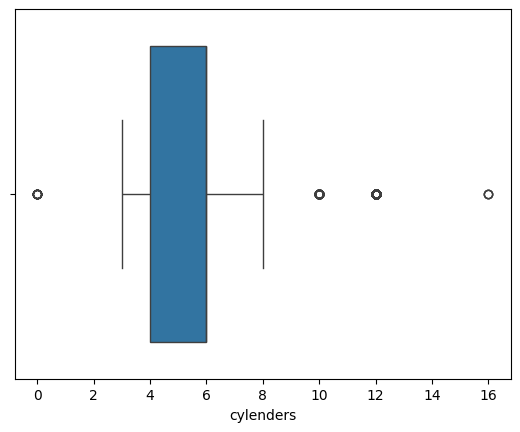

In [54]:
sns.boxplot(x=data['cylenders'])

In [57]:
numeric_data = data.select_dtypes(include=['number'])

# Compute IQR only for numeric columns
Q1 = numeric_data.quantile(0.25)
Q3 = numeric_data.quantile(0.75)
IQR = Q3 - Q1

print(IQR)

Year              9.0
hp              130.0
cylenders         2.0
mpg               8.0
city mpg          6.0
Popularity     1460.0
Price         21465.0
dtype: float64


In [62]:
lower_bound = Q1 - 1.5*IQR
uper_bound = Q3 + 1.5*IQR

outlier = (numeric_data<lower_bound) | (numeric_data> uper_bound)
print(outlier.sum())


Year          461
hp            495
cylenders     309
mpg           129
city mpg      248
Popularity    802
Price         938
dtype: int64


removing iutliers

In [63]:
data_cleaned = numeric_data[~outlier.any(axis=1)]


In [65]:
print("Original shape:", data.shape)
print("Shape after removing outliers:", data_cleaned.shape)

Original shape: (10988, 11)
Shape after removing outliers: (8526, 7)


# **lot different features against one another (scatter), against frequency (histogram)**

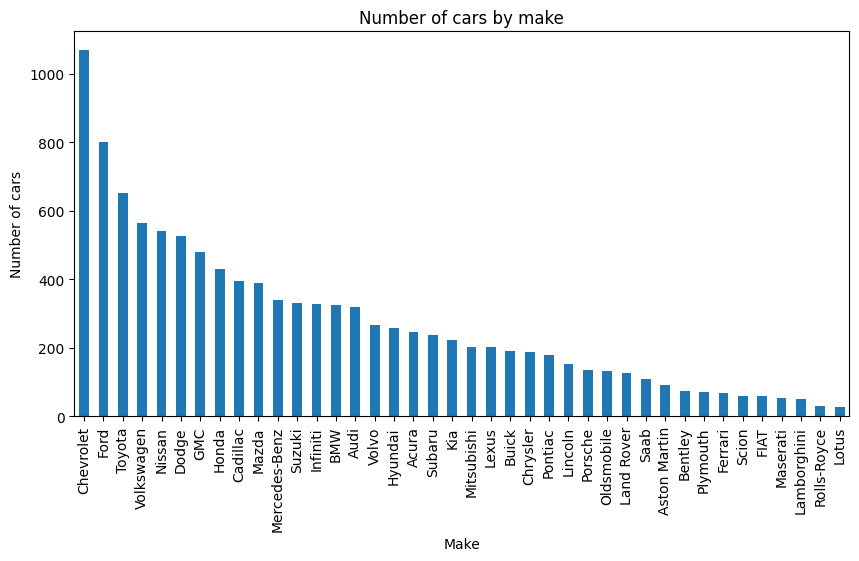

In [68]:
data.Make.value_counts().nlargest(40).plot(kind='bar', figsize=(10,5))
plt.title("Number of cars by make")
plt.ylabel('Number of cars')
plt.xlabel('Make');

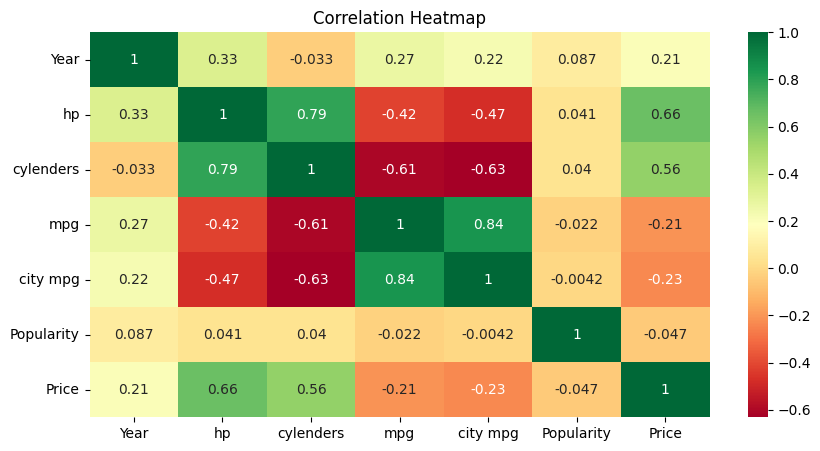

In [72]:
# Select only numeric columns
numeric_data = data.select_dtypes(include=['number'])

# Compute correlation
c = numeric_data.corr()

# Plot heatmap
plt.figure(figsize=(10,5))
sns.heatmap(c, cmap="RdYlGn", annot=True)

plt.title("Correlation Heatmap")
plt.show()

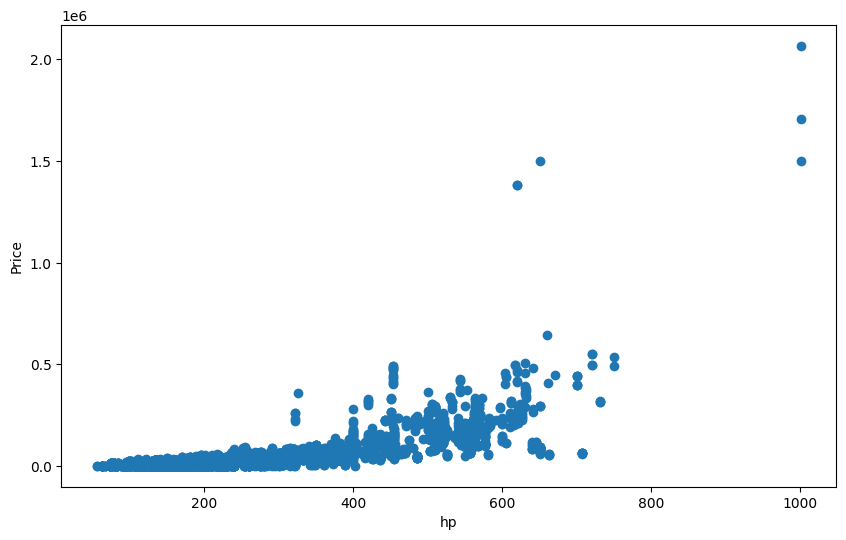

In [74]:
fig, ax = plt.subplots(figsize=(10,6))
ax.scatter(numeric_data['hp'], numeric_data['Price'])
ax.set_xlabel('hp')
ax.set_ylabel('Price')
plt.show()

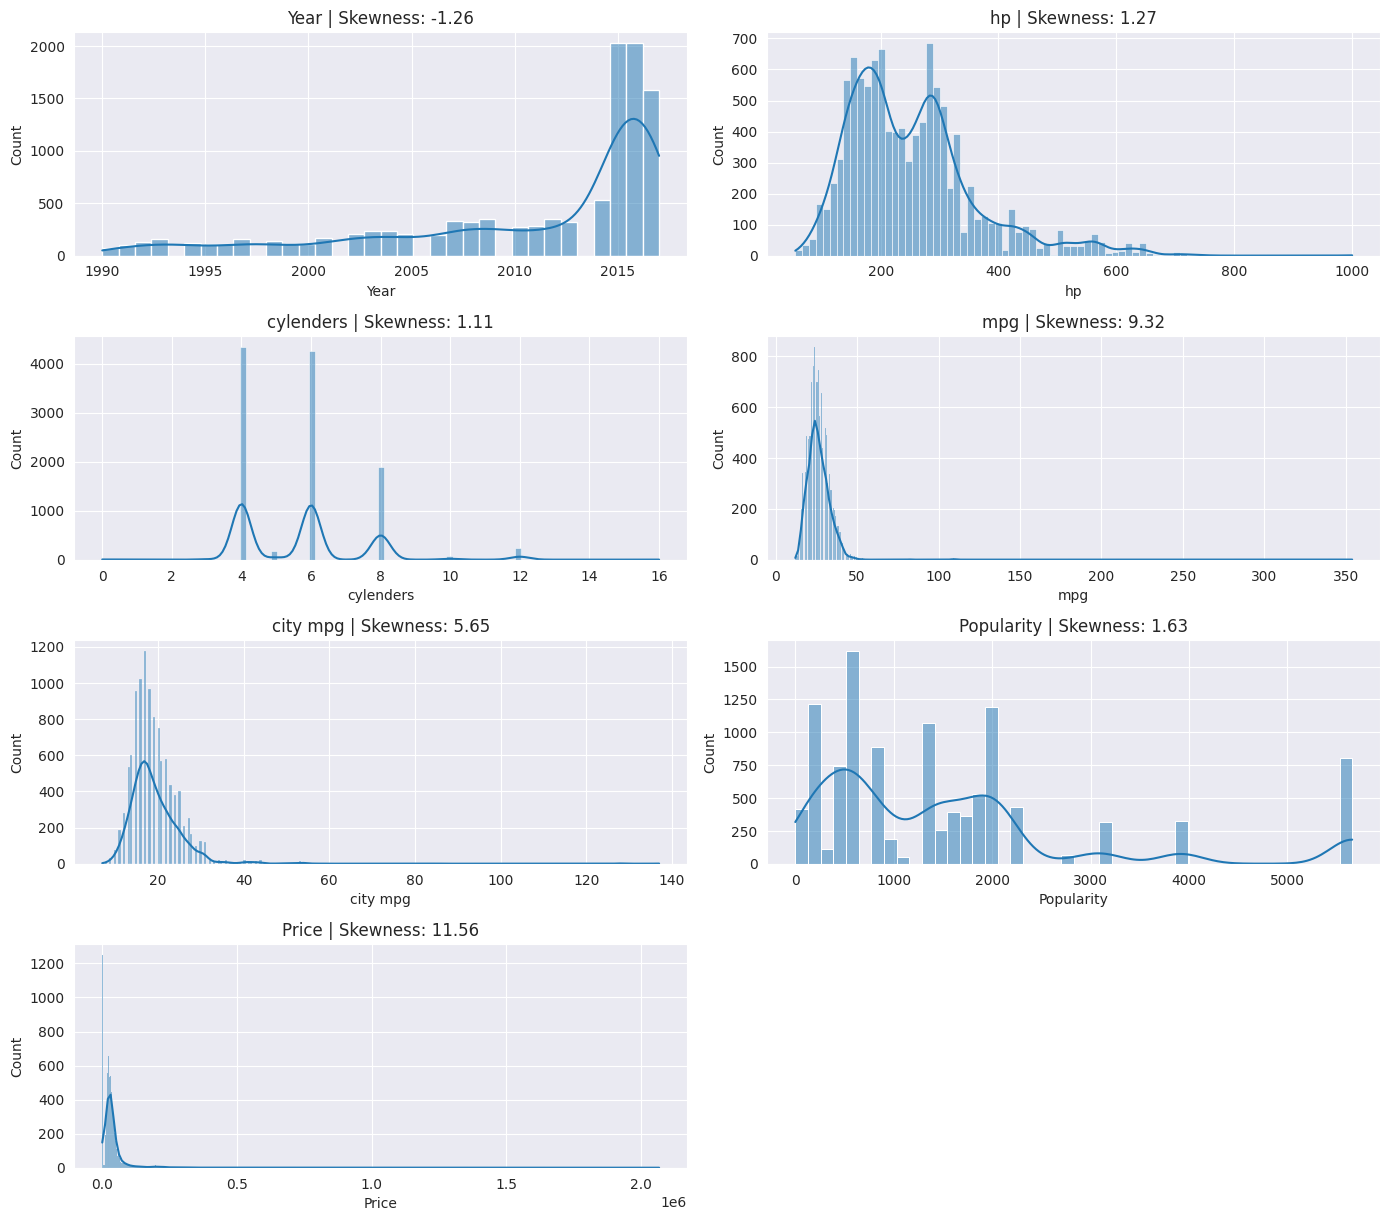

In [78]:
sns.set_style("darkgrid")

numerical_columns = data.select_dtypes(include=["int64", "float64"]).columns

plt.figure(figsize=(14, len(numerical_columns) * 3))
for idx, feature in enumerate(numerical_columns, 1):
    plt.subplot(len(numerical_columns), 2, idx)
    sns.histplot(data[feature], kde=True)
    plt.title(f"{feature} | Skewness: {round(data[feature].skew(), 2)}")

plt.tight_layout()
plt.show()

<ipython-input-79-427cfb094051>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(x="Price", y="hp", data=data, palette='viridis')
/usr/local/lib/python3.11/dist-packages/seaborn/categorical.py:3399: UserWarning: 98.9% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.11/dist-packages/seaborn/categorical.py:3399: UserWarning: 33.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.11/dist-packages/seaborn/categorical.py:3399: UserWarning: 50.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.11/dist-packages/seaborn/catego

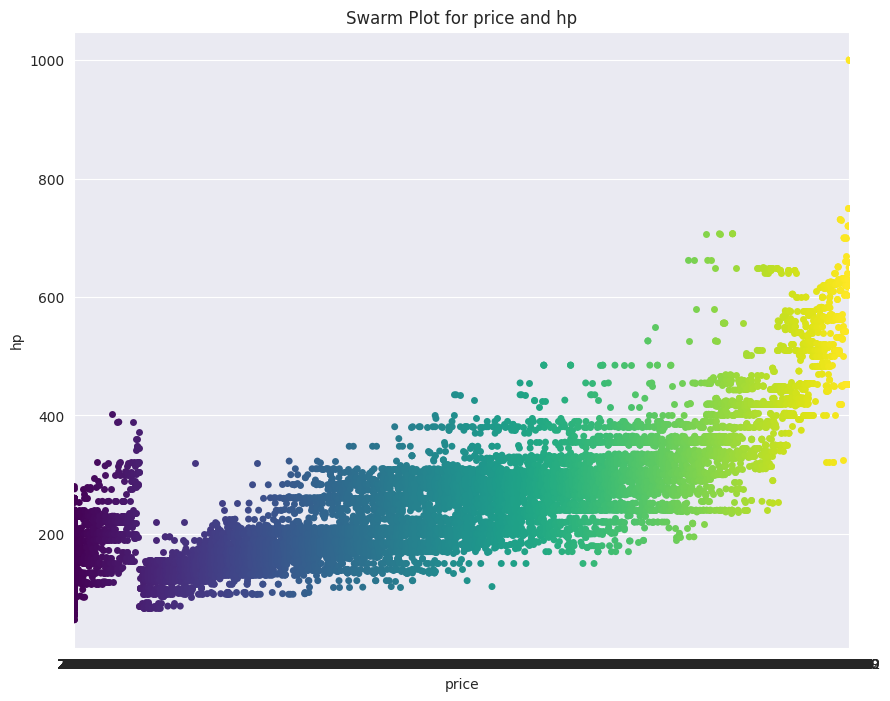

In [79]:
plt.figure(figsize=(10, 8))

sns.swarmplot(x="Price", y="hp", data=data, palette='viridis')

plt.title('Swarm Plot for price and hp')
plt.xlabel('price')
plt.ylabel('hp')
plt.show()

<Figure size 1000x600 with 0 Axes>

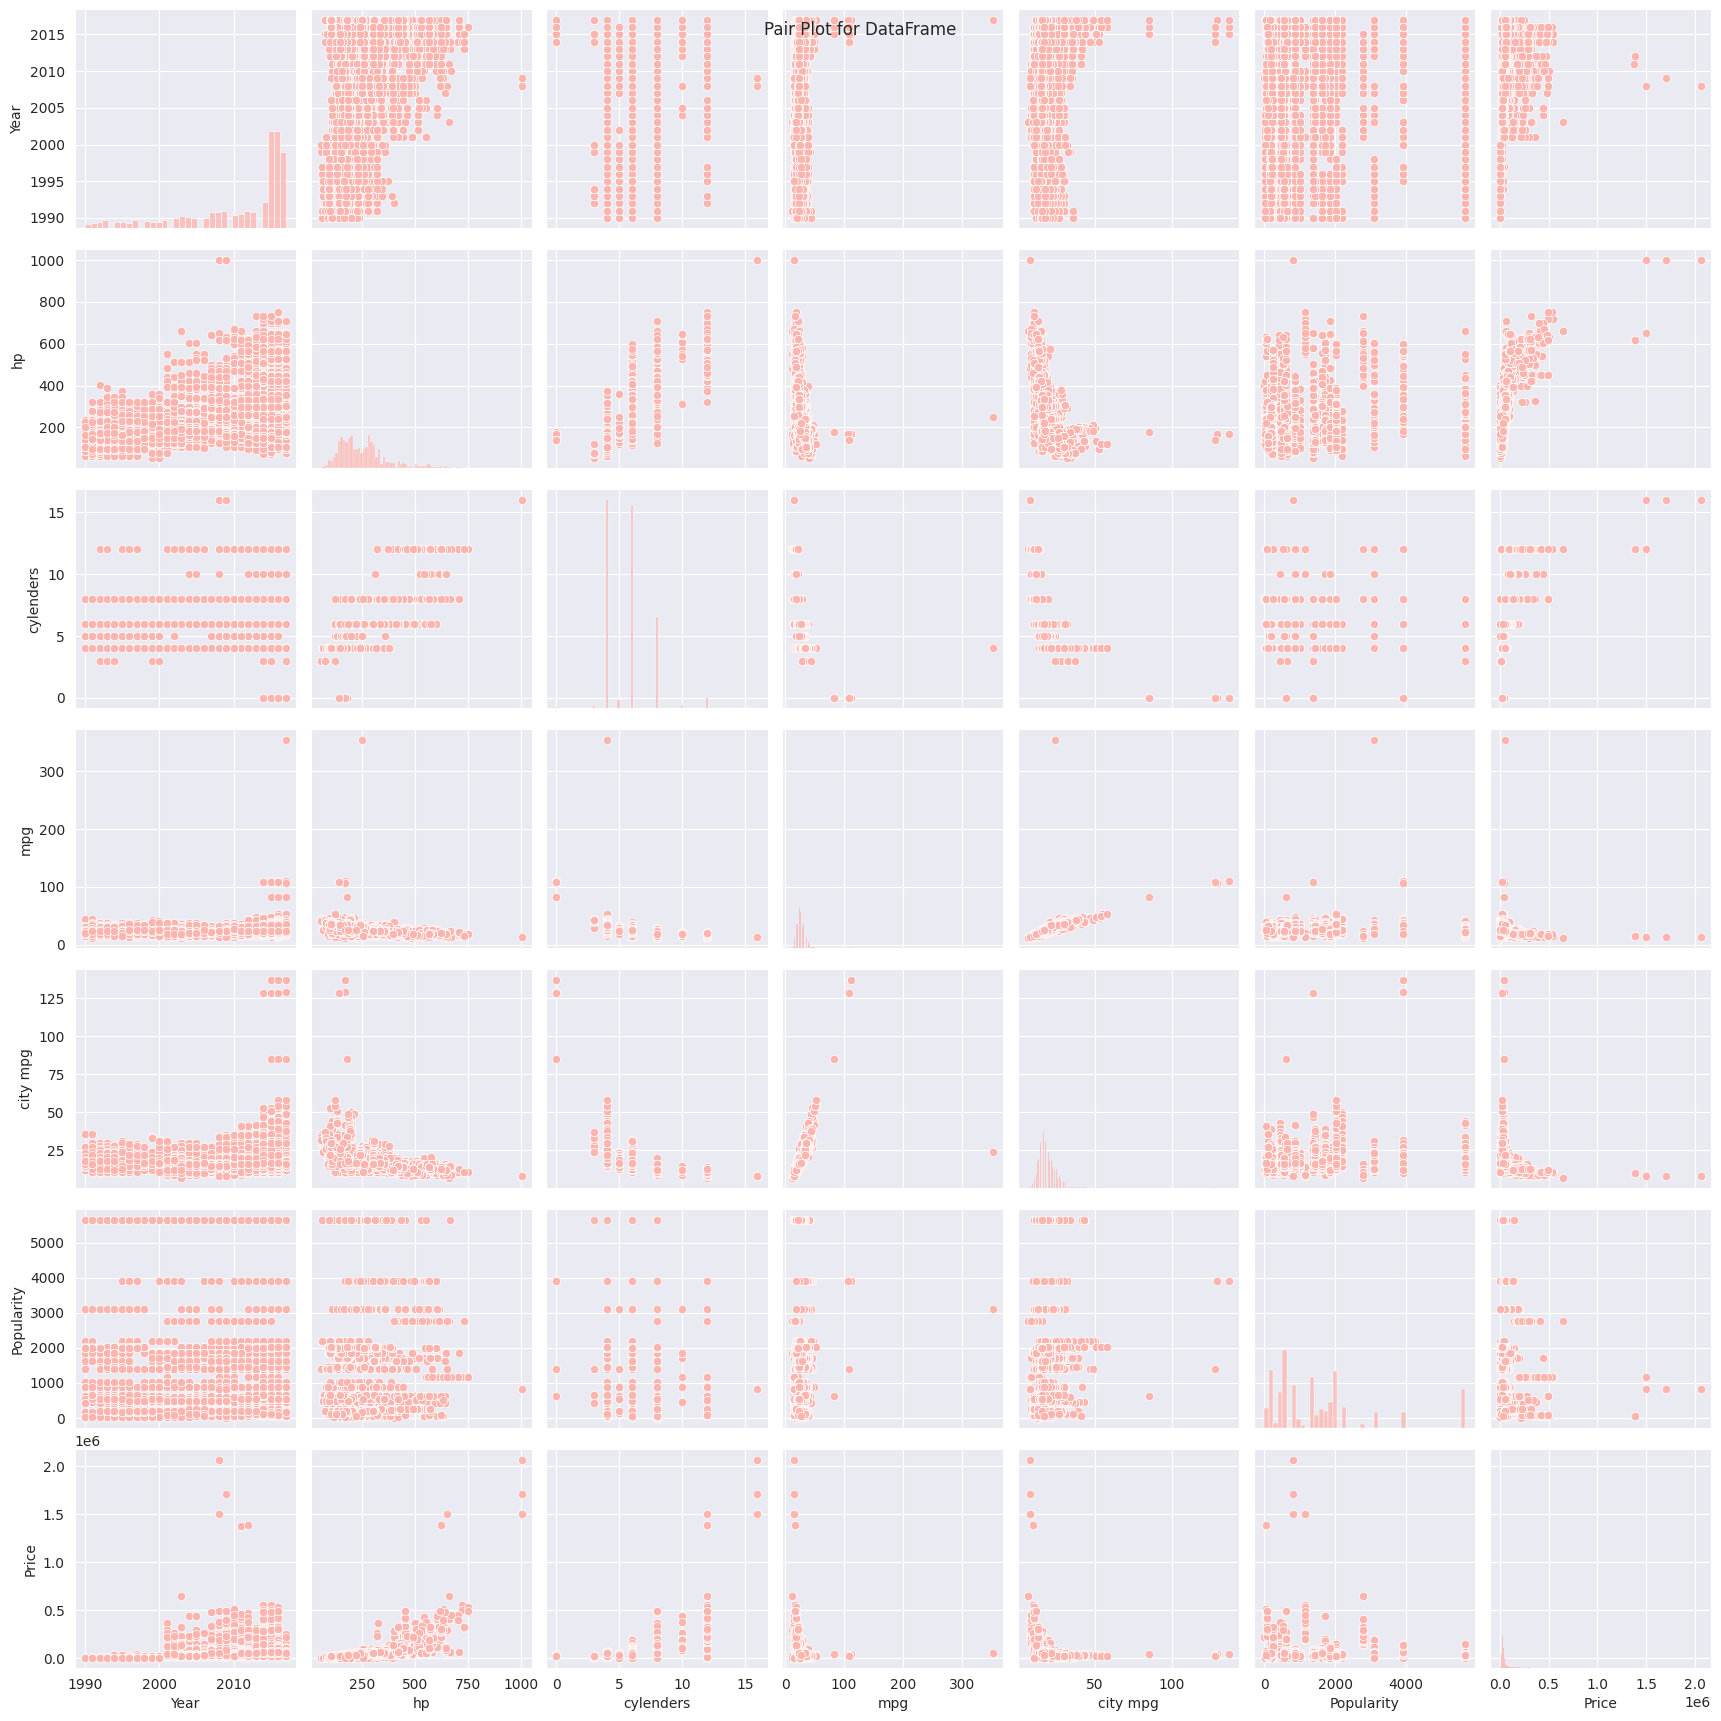

In [83]:
sns.set_palette("Pastel1")

plt.figure(figsize=(10, 6))

sns.pairplot(data)

plt.suptitle('Pair Plot for DataFrame')
plt.show()